<center><h2>ALTeGraD 2024<br>Lab Session 1: HAN</h2><h3>Hierarchical Attention Network Using GRU</h3> 8 / 10 / 2024<br> Dr. Guokan Shang, Yang Zhang<br><br>


<b>Student name:</b> [Antoine Peyronnet]




</center>
In this lab, you will get familiar with recurrent neural networks (RNNs), self-attention, and the HAN architecture <b>(Yang et al. 2016)</b> using PyTorch. In this architecture, sentence embeddings are first individually produced, and a document embedding is then computed from the sentence embeddings.<br>
<b>The deadline for this lab is October 15, 2024 11:59 PM.</b> More details about the submission and the architecture for this lab can be found in the handout PDF.


### = = = = =  Attention Layer = = = = =
In thi section, you will fill the gaps in the code to implement the self-attention layer. This layer will be used later to define the HAN architecture. The basic idea behind attention is that rather than considering the last annotation $h_T$ as a summary of the entire sequence, which is prone to information loss, the annotations at <i>all</i> time steps are used.
The self-attention mechanism computes a weighted sum of the annotations, where the weights are determined by trainable parameters. Refer to <b>section 2.2</b> in the handout for the theoretical part, it will be needed to finish the first task.

#### <b>Task 1:</b>

In [3]:
pip install torch

     |██████████████████████████████▊ | 144.6 MB 1.5 MB/s eta 0:00:04     |██████████████████████▌         | 105.9 MB 518 kB/s eta 0:01:27

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import numpy as np 

class AttentionWithContext(nn.Module):
    """
    Follows the work of Yang et al. [https://www.cs.cmu.edu/~diyiy/docs/naacl16.pdf]
    "Hierarchical Attention Networks for Document Classification"
    by using a context vector to assist the attention
    # Input shape
        3D tensor with shape: `(samples, steps, features)`.
    # Output shape
        2D tensor with shape: `(samples, features)`.
    """
    
    def __init__(self, input_shape, return_coefficients=False, bias=True):
        super(AttentionWithContext, self).__init__()
        self.return_coefficients = return_coefficients

        self.W = nn.Linear(input_shape, input_shape, bias=bias)
        self.tanh = nn.Tanh()
        self.u = nn.Linear(input_shape, 1, bias=False)

        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.W.weight.data.uniform_(-initrange, initrange)
        self.W.bias.data.uniform_(-initrange, initrange)
        self.u.weight.data.uniform_(-initrange, initrange)
    
    def generate_square_subsequent_mask(self, sz):
        # do not pass the mask to the next layers
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = (
            mask.float()
            .masked_fill(mask == 0, float("-inf"))
            .masked_fill(mask == 1, float(0.0))
        )
        return mask
    
    def forward(self, x, mask=None):
        uit = self.W(x) # fill the gap # compute uit = W . x  where x represents ht
        uit = self.tanh(uit)
        ait = self.u(uit)
        a = torch.exp(ait)
        
        # apply mask after the exp. will be re-normalized next
        if mask is not None:
            a = a*mask.double()
        
        # in some cases especially in the early stages of training the sum may be almost zero
        # and this results in NaN's. A workaround is to add a very small positive number ε to the sum.
        eps = 1e-9
        a = a / (torch.sum(a, axis=1, keepdim=True) + eps)
        weighted_input = x*a### fill the gap ### # compute the attentional vector
        if self.return_coefficients:
            return [torch.sum(weighted_input, axis = 1), a] ### [attentional vector, coefficients] ### use torch.sum to compute s
        else:
            return  torch.sum(weighted_input, axis = 1)### attentional vector only ###


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/antoine/anaconda3/envs/Lab1_HAN/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/Users/antoine/anaconda3/envs/Lab1_HAN/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/antoine/anaconda3/envs/Lab1_HAN/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/Users/antoine/ana

Remark: If I m not mistaken, the provided class above initializes the parameters and gives instruction for the forward loop. If we want to train our model we then need to compute for instance a loss function, a backpropagation loop and an optimizer. So this class can be used in a larger module that adjusts `W` and `u` through computations.

### = = = = = Parameters = = = = =
In this section, we define the parameters to use in our training. Such as data path, the embedding dimention <b>d</b>, the GRU layer dimensionality <b>n_units</b>, etc..<br>
The parameter <b>device</b> is used to train the model on GPU if it is available. for this purpose, if you are using Google Colab, switch your runtime to a GPU runtime to train the model with a maximum speed.<br>
<b>Bonus question:</b> What is the purpose of the parameter <i>my_patience</i>?

In [33]:
import sys
import json
import operator
import numpy as np

path_root = ''
path_to_data = path_root + 'data/'

d = 30 # dimensionality of word embeddings
n_units = 50 # RNN layer dimensionality
drop_rate = 0.5 # dropout
mfw_idx = 2 # index of the most frequent words in the dictionary 
            # 0 is for the special padding token
            # 1 is for the special out-of-vocabulary token

padding_idx = 0
oov_idx = 1
batch_size = 64
nb_epochs = 15
my_patience = 2 # for early stopping strategy
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### = = = = = Data Loading = = = = =
In this section we will use first <b>wget</b> to download the data the we will load it using numpy in the first cell. While in the second cell, we will use these data to define our Pytorch data loader. Note that the data is already preprocessed, tokenized and padded.<br><br>
<b>Note: if you are running your notebook on Windows or on MacOS, <i>wget</i> will probably not work if you did not install it manually. In this case, use the provided link to download the data and change the <i>path_to_data</i> in the <i>Parameters</i> section accordingly. Otherwise, you will face no problem on Ubuntu and Google Colab.</b>

#### <b>Task 2.1:</b>

In [4]:
import urllib.request
url = "https://onedrive.live.com/download?cid=AE69638675180117&resid=AE69638675180117%2199289&authkey=AHgxt3xmgG0Fu5A"
output_file = "data.zip"
urllib.request.urlretrieve(url, output_file)

!unzip data.zip


Archive:  data.zip
   creating: data/
  inflating: __MACOSX/._data         
  inflating: data/labels_train.npy   
  inflating: __MACOSX/data/._labels_train.npy  
  inflating: data/docs_test.npy      
  inflating: __MACOSX/data/._docs_test.npy  
  inflating: data/labels_test.npy    
  inflating: __MACOSX/data/._labels_test.npy  
  inflating: data/word_to_index.json  
  inflating: __MACOSX/data/._word_to_index.json  
  inflating: data/docs_train.npy     
  inflating: __MACOSX/data/._docs_train.npy  


In [5]:


my_docs_array_train = np.load(path_to_data + 'docs_train.npy')
my_docs_array_test = np.load(path_to_data + 'docs_test.npy')

my_labels_array_train = np.load(path_to_data + 'labels_train.npy')
my_labels_array_test = np.load(path_to_data + 'labels_test.npy')

# load dictionary of word indexes (sorted by decreasing frequency across the corpus)
with open(path_to_data + 'word_to_index.json', 'r') as my_file:
    word_to_index = json.load(my_file)
    


In [44]:
my_docs_array_train[0].shape

(7, 30)

In [23]:
my_docs_array_train

array([[[    1,    85,    22, ...,    15,   431,     7],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[   68,   152,   354, ...,     3,    60,  1703],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[   11,  4272,    15, ...,    13,    93,   421],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,    

In [22]:
my_labels_array_test[15:20]

array([0, 0, 0, 0, 1])

In [8]:
print(f" type word_to_index : {type(word_to_index)} \n  len(word_to_index): {len(word_to_index)}")

 type word_to_index : <class 'dict'> 
  len(word_to_index): 29936


In [16]:

# invert mapping
index_to_word = {value: index for index, value in word_to_index.items()}  ### fill the gap (use a dict comprehension) ###
input_size = my_docs_array_train.shape

In [51]:
import numpy
import torch
from torch.utils.data import DataLoader, Dataset


class Dataset_(Dataset):
    def __init__(self, x, y):
        self.documents = x
        self.labels = y

    def __len__(self):
        return len(self.documents)

    # def __getitem__(self, index):
    #     document = self.documents[index]
    #     label = self.labels[index] 
    #     sample = {
    #         "document": torch.tensor(document),
    #         "label": torch.tensor(label),
    #         }
    #     return sample
    
    def __getitem__(self, index):
        document = self.documents[index]
        label = self.labels[index] 
        sample = {
            "document": torch.tensor(document, dtype=torch.long),  # Specify dtype
            "label": torch.tensor(label, dtype=torch.long),        # Specify dtype
            }
        return sample



def get_loader(x, y, batch_size=32):
    dataset = Dataset_(x, y)
    data_loader = DataLoader(dataset=dataset,
                            batch_size=batch_size,
                            shuffle=True,
                            pin_memory=True,
                            drop_last=True,
                            )
    return data_loader

### = = = = = Defining Architecture = = = = =
In this section, we define the HAN architecture. We start with <i>AttentionBiGRU</i> module in order to define the sentence encoder (check Figure 3 in the handout). Then, we define the <i>TimeDistributed</i> module to allow us to forward our input (batch of document) as to the sentence encoder as <b>batch of sentences</b>, where each sentence in the document will be considered as a time step. This module also reshape the output to a batch of timesteps representations per document. Finally we define the <b>HAN</b> architecture using <i>TimeDistributed</i>, <i>AttentionWithContext</i> and <i>GRU</i>.

#### <b>Task 2.2:</b>

In [ ]:
# ## un corr
# class AttentionBiGRU(nn.Module):
#     def __init__(self, input_shape, n_units, index_to_word, dropout=0):
#         super(AttentionBiGRU, self).__init__()
#         self.embedding = nn.Embedding(,# fill the gap # vocab size
#                                       input_shape, # dimensionality of embedding space
#                                       padding_idx=0)
#         self.dropout = nn.Dropout(drop_rate) # dropout
#         self.gru = nn.GRU(input_size=input_shape,
#                           hidden_size=n_units,
#                           num_layers=1,
#                           bias=True,
#                           batch_first=True,
#                           bidirectional=True)
#         self.attention = AttentionWithContext(,   # fill the gap # the input shape for the attention layer
#                                               return_coefficients=True)


#     def forward(self, sent_ints):
#         sent_wv = self.embedding(sent_ints)
#         sent_wv_dr = self.dropout(sent_wv)
#         sent_wa, _ = self.gru(sent_wv_dr) # fill the gap # RNN layer
#         sent_att_vec, word_att_coeffs = self.attention(sent_wa) # fill the gap # attentional vector for the sent
#         sent_att_vec_dr = self.dropout(sent_att_vec)     
#         return sent_att_vec_dr, word_att_coeffs

# class TimeDistributed(nn.Module):
#     def __init__(self, module, batch_first=False):
#         super(TimeDistributed, self).__init__()
#         self.module = module
#         self.batch_first = batch_first

#     def forward(self, x):
#         if len(x.size()) <= 2:
#             return self.module(x)
#         # Squash samples and timesteps into a single axis
#         x_reshape = x.contiguous().view(-1, x.size(-1))  # (samples * timesteps, input_size) (448, 30)
#         sent_att_vec_dr, word_att_coeffs = self.module(x_reshape)
#         # We have to reshape the output
#         if self.batch_first:
#             sent_att_vec_dr = sent_att_vec_dr.contiguous().view(x.size(0), -1, sent_att_vec_dr.size(-1))  # (samples, timesteps, output_size)
#             word_att_coeffs = word_att_coeffs.contiguous().view(x.size(0), -1, word_att_coeffs.size(-1))  # (samples, timesteps, output_size)
#         else:
#             sent_att_vec_dr = sent_att_vec_dr.view(-1, x.size(1), sent_att_vec_dr.size(-1))  # (timesteps, samples, output_size)
#             word_att_coeffs = word_att_coeffs.view(-1, x.size(1), word_att_coeffs.size(-1))  # (timesteps, samples, output_size)
#         return sent_att_vec_dr, word_att_coeffs      

# class HAN(nn.Module):
#     def __init__(self, input_shape, n_units, index_to_word, dropout=0):
#         super(HAN, self).__init__()
#         self.encoder = AttentionBiGRU(input_shape, n_units, index_to_word, dropout)
#         self.timeDistributed = TimeDistributed(self.encoder, True)
#         self.dropout = nn.Dropout(drop_rate)
#         self.gru = nn.GRU(input_size=,# fill the gap # the input shape of GRU layer
#                           hidden_size=n_units,
#                           num_layers=1,
#                           bias=True,
#                           batch_first=True,
#                           bidirectional=True)
#         self.attention = AttentionWithContext(, # fill the gap # the input shape of between-sentence attention layer
#                                               return_coefficients=True)
#         self.lin_out = nn.Linear(,   # fill the gap # the input size of the last linear layer
#                                  1)
#         self.preds = nn.Sigmoid()

#     def forward(self, doc_ints):
#         sent_att_vecs_dr, word_att_coeffs = self.timeDistributed(doc_ints) # fill the gap # get sentence representation
#         doc_sa, _ = self.gru(sent_att_vecs_dr)
#         doc_att_vec, sent_att_coeffs = self.attention(doc_sa)
#         doc_att_vec_dr = self.dropout(doc_att_vec)
#         doc_att_vec_dr = self.lin_out(doc_att_vec_dr)
#         return self.preds(doc_att_vec_dr), word_att_coeffs, sent_att_coeffs


In [61]:

class AttentionBiGRU(nn.Module):
    def __init__(self, input_shape, n_units, index_to_word, dropout=0):
        super(AttentionBiGRU, self).__init__()
        self.embedding = nn.Embedding(len(index_to_word)+2,# fill the gap # vocab size
                                      d, # dimensionality of embedding space  # input shape no
                                      padding_idx=0)
        self.dropout = nn.Dropout(drop_rate) # dropout
        self.gru = nn.GRU(input_size=d,
                          hidden_size=n_units,
                          num_layers=1,
                          bias=True,
                          batch_first=True,
                          bidirectional=True)
        self.attention = AttentionWithContext(n_units * 2,   # fill the gap # the input shape for the attention layer
                                              return_coefficients=True)


    def forward(self, sent_ints):
        sent_wv = self.embedding(sent_ints)
        sent_wv_dr = self.dropout(sent_wv)
        sent_wa, _ = self.gru(sent_wv_dr) # fill the gap # RNN layer
        sent_att_vec, word_att_coeffs = self.attention(sent_wa) # fill the gap # attentional vector for the sent
        sent_att_vec_dr = self.dropout(sent_att_vec)     
        return sent_att_vec_dr, word_att_coeffs

class TimeDistributed(nn.Module):
    def __init__(self, module, batch_first=False):
        super(TimeDistributed, self).__init__()
        self.module = module
        self.batch_first = batch_first

    def forward(self, x):
        if len(x.size()) <= 2:
            return self.module(x)
        # Squash samples and timesteps into a single axis
        x_reshape = x.contiguous().view(-1, x.size(-1))  # (samples * timesteps, input_size) (448, 30)
        sent_att_vec_dr, word_att_coeffs = self.module(x_reshape)
        # We have to reshape the output
        if self.batch_first:
            sent_att_vec_dr = sent_att_vec_dr.contiguous().view(x.size(0), -1, sent_att_vec_dr.size(-1))  # (samples, timesteps, output_size)
            word_att_coeffs = word_att_coeffs.contiguous().view(x.size(0), -1, word_att_coeffs.size(-1))  # (samples, timesteps, output_size)
        else:
            sent_att_vec_dr = sent_att_vec_dr.view(-1, x.size(1), sent_att_vec_dr.size(-1))  # (timesteps, samples, output_size)
            word_att_coeffs = word_att_coeffs.view(-1, x.size(1), word_att_coeffs.size(-1))  # (timesteps, samples, output_size)
        return sent_att_vec_dr, word_att_coeffs      

class HAN(nn.Module):
    def __init__(self, input_shape, n_units, index_to_word, dropout=0):
        super(HAN, self).__init__()
        self.encoder = AttentionBiGRU(input_shape, n_units, index_to_word, dropout)
        self.timeDistributed = TimeDistributed(self.encoder, True)
        self.dropout = nn.Dropout(drop_rate)
        self.gru = nn.GRU(input_size=n_units*2,# fill the gap # the input shape of GRU layer
                          hidden_size=n_units,
                          num_layers=1,
                          bias=True,
                          batch_first=True,
                          bidirectional=True)
        self.attention = AttentionWithContext(n_units * 2, # fill the gap # the input shape of between-sentence attention layer
                                              return_coefficients=True)
        self.lin_out = nn.Linear(n_units * 2,   # fill the gap # the input size of the last linear layer
                                 1)
        self.preds = nn.Sigmoid()

    def forward(self, doc_ints):
        sent_att_vecs_dr, word_att_coeffs = self.timeDistributed(doc_ints) # fill the gap # get sentence representation
        doc_sa, _ = self.gru(sent_att_vecs_dr)
        doc_att_vec, sent_att_coeffs = self.attention(doc_sa)
        doc_att_vec_dr = self.dropout(doc_att_vec)
        doc_att_vec_dr = self.lin_out(doc_att_vec_dr)
        return self.preds(doc_att_vec_dr), word_att_coeffs, sent_att_coeffs


### = = = = = Training = = = = =
In this section, we have two code cells. In the first one, we define our evaluation function to compute the training and validation accuracies. While in the second one, we define our model, loss and optimizer and train the model over <i>nb_epochs</i>.<br>
<b>Bonus task:</b> use <a href="https://pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html" target="_blank">tensorboard</a> to visualize the loss and the validation accuray during the training.

#### <b>Task 2.3:</b>

In [62]:
def evaluate_accuracy(data_loader, verbose=True):
    model.eval()
    total_loss = 0.0
    ncorrect = ntotal = 0
    with torch.no_grad():
        for idx, data in enumerate(data_loader):
            # inference 
            output = model(data["document"].to(device))[0] 
            output = output[:, -1] # only last vector
            # total number of examples
            ntotal +=  output.shape[0]
            # number of correct predictions 
            correct_labels = data["label"].to(device)
            predictions = torch.round(output)
            ncorrect += torch.sum(predictions == correct_labels) #fill me # number of correct prediction - hint: use torch.sum 
        acc = ncorrect.item() / ntotal
        if verbose:
          print("validation accuracy: {:3.2f}".format(acc*100))
        return acc

Remark: our `Han` model already uses a sigmoid at the end and it's used for a binary classification task. So let's use a `Binary Cross Entropy` loss function as suggested

In [38]:
input_size

(25000, 7, 30)

We understand that each word is a (7,1) vector
also check the `my_docs_array_train` for each matrix in it (each sentence) each column is a word. 

In [40]:
len(index_to_word)

29936

In [45]:
input_size

(25000, 7, 30)

In [63]:
from tqdm import tqdm

model = HAN(input_size, n_units, index_to_word).to(device)
model = model.double()
lr = 0.001  # learning rate
criterion = torch.nn.BCELoss() # fill the gap, use Binary cross entropy from torch.nn: https://pytorch.org/docs/stable/nn.html#loss-functions
optimizer = torch.optim.Adam(model.parameters(), lr=lr) #fill me

def train(x_train=my_docs_array_train,
          y_train=my_labels_array_train,
          x_test=my_docs_array_test,
          y_test=my_labels_array_test,
          word_dict=index_to_word,
          batch_size=batch_size):
  
    train_data = get_loader(x_train, y_train, batch_size)
    test_data = get_loader(my_docs_array_test, my_labels_array_test, batch_size)

    best_validation_acc = 0.0
    p = 0 # patience

    for epoch in range(1, nb_epochs + 1): 
        losses = []
        accuracies = []
        with tqdm(train_data, unit="batch") as tepoch:
            for idx, data in enumerate(tepoch):
                tepoch.set_description(f"Epoch {epoch}")
                model.train()
                optimizer.zero_grad()
                input = data['document'].to(device)
                label = data['label'].to(device)
                label = label.double()
                output = model.forward(input)[0]
                output = output[:, -1]
                loss = criterion(output, label)# fill the gap # compute the loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5) # prevent exploding gradient 
                optimizer.step()

                losses.append(loss.item())
                accuracy = torch.sum(torch.round(output) == label).item() / batch_size
                accuracies.append(accuracy)
                tepoch.set_postfix(loss=sum(losses)/len(losses), accuracy=100. * sum(accuracies)/len(accuracies))

        # train_acc = evaluate_accuracy(train_data, False)
        test_acc = evaluate_accuracy(test_data, False)
        print("===> Epoch {} Complete: Avg. Loss: {:.4f}, Validation Accuracy: {:3.2f}%"
              .format(epoch, sum(losses)/len(losses), 100.*test_acc))
        if test_acc >= best_validation_acc:
            best_validation_acc = test_acc
            print("Validation accuracy improved, saving model...")
            torch.save(model.state_dict(), './best_model.pt')
            p = 0
            print()
        else:
            p += 1
            if p==my_patience:
                print("Validation accuracy did not improve for {} epochs, stopping training...".format(my_patience))
    print("Loading best checkpoint...")    
    model.load_state_dict(torch.load('./best_model.pt'))
    model.eval()
    print('done.')

train()

Epoch 1: 100%|██████████| 390/390 [03:43<00:00,  1.75batch/s, accuracy=58.2, loss=0.668]


===> Epoch 1 Complete: Avg. Loss: 0.6677, Validation Accuracy: 66.79%
Validation accuracy improved, saving model...



Epoch 2: 100%|██████████| 390/390 [04:34<00:00,  1.42batch/s, accuracy=70.1, loss=0.574]


===> Epoch 2 Complete: Avg. Loss: 0.5737, Validation Accuracy: 72.40%
Validation accuracy improved, saving model...



Epoch 3: 100%|██████████| 390/390 [03:03<00:00,  2.12batch/s, accuracy=75.5, loss=0.503]


...

===> Epoch 13 Complete: Avg. Loss: 0.2854, Validation Accuracy: 84.78%


Epoch 14: 100%|██████████| 390/390 [03:00<00:00,  2.16batch/s, accuracy=88.4, loss=0.279]


===> Epoch 14 Complete: Avg. Loss: 0.2790, Validation Accuracy: 84.98%
Validation accuracy did not improve for 2 epochs, stopping training...


Epoch 15: 100%|██████████| 390/390 [03:19<00:00,  1.96batch/s, accuracy=88.9, loss=0.269]


===> Epoch 15 Complete: Avg. Loss: 0.2689, Validation Accuracy: 85.00%
Validation accuracy improved, saving model...

Loading best checkpoint...
done.


### = = = = = Extraction of Attention Coefficients = = = = =
In this section, we will extract and display the attention coefficients on two levels: sentence level and word level. To do so, we will extract the corresponding weights from our model.
#### <b>Task 3:</b>

In [64]:
model_saved = np.savez(model)

TypeError: expected str, bytes or os.PathLike object, not HAN

In [65]:
# select last review:
my_review = my_docs_array_test[-1:,:,:]
 
# convert integer review to text:
index_to_word[1] = 'OOV'
my_review_text = [[index_to_word[idx] for idx in sent if idx in index_to_word] for sent in my_review.tolist()[0]]

###   &emsp;&emsp;  = = = = = Attention Over Sentences in the Document = = = = =

In [68]:
my_review

array([[[  130,    14,     6,  1991,    28,    22,  2746, 17943,    13,
           564,    85,     1,  3225,     1,    25,    26,    29,   488,
           697,    13,     3,    84,    27,    29,    45,    24,     0,
             0,     0,     0],
        [ 1623,    63,    14,     6,   100,   869,     7,    97,    13,
           856,    84,    31,    92,     2,   236,     7,    15,    20,
             3,    11,   283,    46,     8,  7216,    82,  3013,     7,
           184,     2,   128],
        [  209,   424,    32,  3395,    54,     3,    37,   720,   833,
             7,    15,    20,     9,    31,  8191,     4,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0],
        [  149,    29,    32,     2,   302,     7, 29798,     3,    29,
            67,     1,    18,    39,   317,    38,   600,  1955,    14,
         16966,   325,     1,     8,     1, 29798,    18,    25,    26,
            74,   783,   378],
        [  1

In [69]:
my_review_copy = my_review

In [88]:
my_review_copy_converted = np.array(my_review_copy.tolist(), dtype = float)

In [90]:
type(my_review_copy.tolist()[0][0][0])

int

In [81]:
my_review_copy.shape

(1, 7, 30)

In [74]:
my_review[0][1][0]

np.int64(1623)

In [91]:
my_review_copy_to_list = my_review_copy.tolist()

In [92]:
sent_coeffs = model(torch.tensor(my_review_copy_to_list))[2]# fill the gap # get sentence attention coeffs by passing the review to the model - (you need to convert the inout torch tensor)
sent_coeffs = sent_coeffs[0,:,:]

for elt in zip(sent_coeffs[:,0].tolist(),[' '.join(elt) for elt in my_review_text]):
    print(round(elt[0]*100,2),elt[1])

13.88 There 's a sign on The Lost Highway that says : OOV SPOILERS OOV ( but you already knew that , did n't you ? )
17.2 Since there 's a great deal of people that apparently did not get the point of this movie , I 'd like to contribute my interpretation of why the plot
13.06 As others have pointed out , one single viewing of this movie is not sufficient .
16.54 If you have the DVD of MD , you can OOV ' by looking at David Lynch 's 'Top 10 OOV to OOV MD ' ( but only upon second
14.86 ; ) First of all , Mulholland Drive is downright brilliant .
12.64 A masterpiece .
11.83 This is the kind of movie that refuse to leave your head .


### &emsp;&emsp; = = = = = Attention Over Words in Each Sentence = = = = =

In [111]:
word_coeffs_list

[[0.05160929405783267,
  0.03269733280335586,
  0.03438882996724585,
  0.04641589701701813,
  0.034736583224095945,
  0.035459048447570245,
  0.047600189853725126,
  0.03536792865042334,
  0.03408466977100953,
  0.02964736296474046,
  0.03457109572676374,
  0.02602307118469053,
  0.025665092072781684,
  0.02497246399190518,
  0.024047027443008996,
  0.023769562065133844,
  0.030716867148189792,
  0.03581578050176142,
  0.037456937102765354,
  0.03671989850707907,
  0.030110264168688467,
  0.029424678110093853,
  0.02553389971431569,
  0.036985485573069424,
  0.05045356625851438,
  0.02983713645936706,
  0.029230282335089872,
  0.02883220670131599,
  0.028717284078132992,
  0.02911026400339328],
 [0.054310201693781084,
  0.04025420650278705,
  0.03998149037051648,
  0.03916445427259244,
  0.05902630161007681,
  0.04286159555253274,
  0.03411587766009637,
  0.037028115313343594,
  0.02746237647392442,
  0.025010526524407658,
  0.022664720471740424,
  0.021412863163091364,
  0.02024598752

In [112]:
text_word_coeffs

[[('There', 0.05160929405783267),
  ("'s", 0.03269733280335586),
  ('a', 0.03438882996724585),
  ('sign', 0.04641589701701813),
  ('on', 0.034736583224095945),
  ('The', 0.035459048447570245),
  ('Lost', 0.047600189853725126),
  ('Highway', 0.03536792865042334),
  ('that', 0.03408466977100953),
  ('says', 0.02964736296474046),
  (':', 0.03457109572676374),
  ('OOV', 0.02602307118469053),
  ('SPOILERS', 0.025665092072781684),
  ('OOV', 0.02497246399190518),
  ('(', 0.024047027443008996),
  ('but', 0.023769562065133844),
  ('you', 0.030716867148189792),
  ('already', 0.03581578050176142),
  ('knew', 0.037456937102765354),
  ('that', 0.03671989850707907),
  (',', 0.030110264168688467),
  ('did', 0.029424678110093853),
  ("n't", 0.02553389971431569),
  ('you', 0.036985485573069424),
  ('?', 0.05045356625851438),
  (')', 0.02983713645936706)],
 [('Since', 0.054310201693781084),
  ('there', 0.04025420650278705),
  ("'s", 0.03998149037051648),
  ('a', 0.03916445427259244),
  ('great', 0.05902

In [94]:
word_coeffs = model(torch.tensor(my_review_copy_to_list))[1]# fill the gap # get words attention coeffs by passing the review to the model - (you need to convert the inout torch tensor)

word_coeffs_list = word_coeffs.reshape(7,30).tolist()

# match text and coefficients:
text_word_coeffs = [list(zip(words,word_coeffs_list[idx][:len(words)])) for idx,words in enumerate(my_review_text)]

for sent in text_word_coeffs:
    [print(elt) for elt in sent]
    print('= = = =')

# sort words by importance within each sentence:
text_word_coeffs_sorted = [sorted(elt,key=operator.itemgetter(1),reverse=True) for elt in text_word_coeffs]

for sent in text_word_coeffs_sorted:
    [print(elt) for elt in sent]
    print('= = = =')

('There', 0.05160929405783267)
("'s", 0.03269733280335586)
('a', 0.03438882996724585)
('sign', 0.04641589701701813)
('on', 0.034736583224095945)
('The', 0.035459048447570245)
('Lost', 0.047600189853725126)
('Highway', 0.03536792865042334)
('that', 0.03408466977100953)
('says', 0.02964736296474046)
(':', 0.03457109572676374)
('OOV', 0.02602307118469053)
('SPOILERS', 0.025665092072781684)
('OOV', 0.02497246399190518)
('(', 0.024047027443008996)
('but', 0.023769562065133844)
('you', 0.030716867148189792)
('already', 0.03581578050176142)
('knew', 0.037456937102765354)
('that', 0.03671989850707907)
(',', 0.030110264168688467)
('did', 0.029424678110093853)
("n't", 0.02553389971431569)
('you', 0.036985485573069424)
('?', 0.05045356625851438)
(')', 0.02983713645936706)
= = = =
('Since', 0.054310201693781084)
('there', 0.04025420650278705)
("'s", 0.03998149037051648)
('a', 0.03916445427259244)
('great', 0.05902630161007681)
('deal', 0.04286159555253274)
('of', 0.03411587766009637)
('people', 0.

In [10]:
word_coeffs = model(torch.tensor(my_review))[1]# fill the gap # get words attention coeffs by passing the review to the model - (you need to convert the inout torch tensor)

word_coeffs_list = word_coeffs.reshape(7,30).tolist()

# match text and coefficients:
text_word_coeffs = [list(zip(words,word_coeffs_list[idx][:len(words)])) for idx,words in enumerate(my_review_text)]

for sent in text_word_coeffs:
    [print(elt) for elt in sent]
    print('= = = =')

# sort words by importance within each sentence:
text_word_coeffs_sorted = [sorted(elt,key=operator.itemgetter(1),reverse=True) for elt in text_word_coeffs]

for sent in text_word_coeffs_sorted:
    [print(elt) for elt in sent]
    print('= = = =')

('There', 0.09504965432890092)
("'s", 0.034071130570874596)
('a', 0.026581112935931225)
('sign', 0.06942056774481532)
('on', 0.02841534941445415)
('The', 0.025070646019500518)
('Lost', 0.021440765209565317)
('Highway', 0.02832753608167572)
('that', 0.030535255778292702)
('says', 0.0294035649861619)
(':', 0.01880419131560501)
('OOV', 0.014847159617598426)
('SPOILERS', 0.03214859825910152)
('OOV', 0.014818570609542355)
('(', 0.019769434381137853)
('but', 0.024909963744457825)
('you', 0.027747772848384915)
('already', 0.04428184476384545)
('knew', 0.05447869809716605)
('that', 0.04861536863927533)
(',', 0.026859509597772946)
('did', 0.05530394714062024)
("n't", 0.026164396330751565)
('you', 0.02198598424866895)
('?', 0.027090882511521194)
(')', 0.03341286532114622)
= = = =
('Since', 0.07018808490189818)
('there', 0.043871160365625085)
("'s", 0.03317797174302763)
('a', 0.02792839621373684)
('great', 0.07855391286686068)
('deal', 0.03138065375003498)
('of', 0.021066594369817088)
('people', 

In [97]:
type(text_word_coeffs_sorted)

list

In [101]:
text_word_coeffs_sorted[0][0][1]

0.05160929405783267

In [102]:
text_word_coeffs_sorted_array = np.array(text_word_coeffs_sorted[0][1])

In [107]:
text_word_coeffs_sorted_array_coefficient = [text_word_coeffs_sorted[0][i][1] for i in range(len(text_word_coeffs_sorted))]

In [109]:
text_word_coeffs_sorted_array_coefficient_array = np.array(text_word_coeffs_sorted_array_coefficient)

In [126]:
text_word_coeffs_total = []
for i in range(len(text_word_coeffs)):
    text_word_coeffs_total += text_word_coeffs[i]

In [127]:
text_word_coeffs_total

[('There', 0.05160929405783267),
 ("'s", 0.03269733280335586),
 ('a', 0.03438882996724585),
 ('sign', 0.04641589701701813),
 ('on', 0.034736583224095945),
 ('The', 0.035459048447570245),
 ('Lost', 0.047600189853725126),
 ('Highway', 0.03536792865042334),
 ('that', 0.03408466977100953),
 ('says', 0.02964736296474046),
 (':', 0.03457109572676374),
 ('OOV', 0.02602307118469053),
 ('SPOILERS', 0.025665092072781684),
 ('OOV', 0.02497246399190518),
 ('(', 0.024047027443008996),
 ('but', 0.023769562065133844),
 ('you', 0.030716867148189792),
 ('already', 0.03581578050176142),
 ('knew', 0.037456937102765354),
 ('that', 0.03671989850707907),
 (',', 0.030110264168688467),
 ('did', 0.029424678110093853),
 ("n't", 0.02553389971431569),
 ('you', 0.036985485573069424),
 ('?', 0.05045356625851438),
 (')', 0.02983713645936706),
 ('Since', 0.054310201693781084),
 ('there', 0.04025420650278705),
 ("'s", 0.03998149037051648),
 ('a', 0.03916445427259244),
 ('great', 0.05902630161007681),
 ('deal', 0.04286

In [129]:
words_total = [pair[0] for pair in text_word_coeffs_total]
coefficients_total = [pair[1] for pair in text_word_coeffs_total]

In [116]:
import matplotlib.pyplot as plt
import numpy as np

data = [
    [('There', 0.0516), ("'s", 0.0327), ('a', 0.0344), ('sign', 0.0464), ('on', 0.0347), 
     ('The', 0.0355), ('Lost', 0.0476), ('Highway', 0.0354), ('that', 0.0341), 
     ('says', 0.0296), (':', 0.0346), ('OOV', 0.0260), ('SPOILERS', 0.0257), 
     ('OOV', 0.0250), ('(', 0.0240), ('but', 0.0238), ('you', 0.0307), ('already', 0.0358), 
     ('knew', 0.0375), ('that', 0.0367), (',', 0.0301), ('did', 0.0294), ("n't", 0.0255), 
     ('you', 0.0370), ('?', 0.0505), (')', 0.0298)],
    [('Since', 0.0543), ('there', 0.0403), ("'s", 0.0400), ('a', 0.0392), ('great', 0.0590), 
     ('deal', 0.0429), ('of', 0.0341), ('people', 0.0370), ('that', 0.0275), 
     ('apparently', 0.0250), ('did', 0.0227), ('not', 0.0214), ('get', 0.0202), 
     ('the', 0.0211), ('point', 0.0276), ('of', 0.0212), ('this', 0.0230), 
     ('movie', 0.0271), (',', 0.0325), ('I', 0.0277), ("'d", 0.0421), 
     ('like', 0.0384), ('to', 0.0299), ('contribute', 0.0356), ('my', 0.0333), 
     ('interpretation', 0.0477), ('of', 0.0356), ('why', 0.0241), ('the', 0.0278), 
     ('plot', 0.0419)],
    [('As', 0.0320), ('others', 0.0341), ('have', 0.0264), ('pointed', 0.0295), 
     ('out', 0.0354), (',', 0.0365), ('one', 0.0416), ('single', 0.0580), 
     ('viewing', 0.0592), ('of', 0.0380), ('this', 0.0359), ('movie', 0.0387), 
     ('is', 0.0495), ('not', 0.0606), ('sufficient', 0.0305), ('.', 0.0284)],
    [('If', 0.0489), ('you', 0.0323), ('have', 0.0269), ('the', 0.0260), 
     ('DVD', 0.0385), ('of', 0.0285), ('MD', 0.0348), (',', 0.0315), 
     ('you', 0.0348), ('can', 0.0464), ('OOV', 0.0297), ("'", 0.0266), 
     ('by', 0.0313), ('looking', 0.0426), ('at', 0.0618), ('David', 0.0351), 
     ('Lynch', 0.0346), ("'s", 0.0321), ("'Top", 0.0350), ('10', 0.0321), 
     ('OOV', 0.0294), ('to', 0.0253), ('OOV', 0.0229), ('MD', 0.0328), 
     ("'", 0.0244), ('(', 0.0236), ('but', 0.0235), ('only', 0.0352), 
     ('upon', 0.0386), ('second', 0.0348)],
    [(';', 0.0412), (')', 0.0415), ('First', 0.0516), ('of', 0.0242), 
     ('all', 0.0238), (',', 0.0296), ('Mulholland', 0.0375), ('Drive', 0.0385), 
     ('is', 0.0383), ('downright', 0.0577), ('brilliant', 0.1039), ('.', 0.0454)],
    [('A', 0.0795), ('masterpiece', 0.0881), ('.', 0.0485)],
    [('This', 0.0426), ('is', 0.0547), ('the', 0.0883), ('kind', 0.1012), 
     ('of', 0.0406), ('movie', 0.0438), ('that', 0.0375), ('refuse', 0.0265), 
     ('to', 0.0268), ('leave', 0.0276), ('your', 0.0278), ('head', 0.0484), 
     ('.', 0.0311)]
]

words = [[pair[0] for pair in row] for row in data]
coefficients = [[pair[1] for pair in row] for row in data]


In [119]:
coefficients

[[0.0516,
  0.0327,
  0.0344,
  0.0464,
  0.0347,
  0.0355,
  0.0476,
  0.0354,
  0.0341,
  0.0296,
  0.0346,
  0.026,
  0.0257,
  0.025,
  0.024,
  0.0238,
  0.0307,
  0.0358,
  0.0375,
  0.0367,
  0.0301,
  0.0294,
  0.0255,
  0.037,
  0.0505,
  0.0298],
 [0.0543,
  0.0403,
  0.04,
  0.0392,
  0.059,
  0.0429,
  0.0341,
  0.037,
  0.0275,
  0.025,
  0.0227,
  0.0214,
  0.0202,
  0.0211,
  0.0276,
  0.0212,
  0.023,
  0.0271,
  0.0325,
  0.0277,
  0.0421,
  0.0384,
  0.0299,
  0.0356,
  0.0333,
  0.0477,
  0.0356,
  0.0241,
  0.0278,
  0.0419],
 [0.032,
  0.0341,
  0.0264,
  0.0295,
  0.0354,
  0.0365,
  0.0416,
  0.058,
  0.0592,
  0.038,
  0.0359,
  0.0387,
  0.0495,
  0.0606,
  0.0305,
  0.0284],
 [0.0489,
  0.0323,
  0.0269,
  0.026,
  0.0385,
  0.0285,
  0.0348,
  0.0315,
  0.0348,
  0.0464,
  0.0297,
  0.0266,
  0.0313,
  0.0426,
  0.0618,
  0.0351,
  0.0346,
  0.0321,
  0.035,
  0.0321,
  0.0294,
  0.0253,
  0.0229,
  0.0328,
  0.0244,
  0.0236,
  0.0235,
  0.0352,
  0.0386,
  

In [121]:


coefficients = np.array([coefficients[0]])



In [145]:
coefficients.shape

(1, 26)

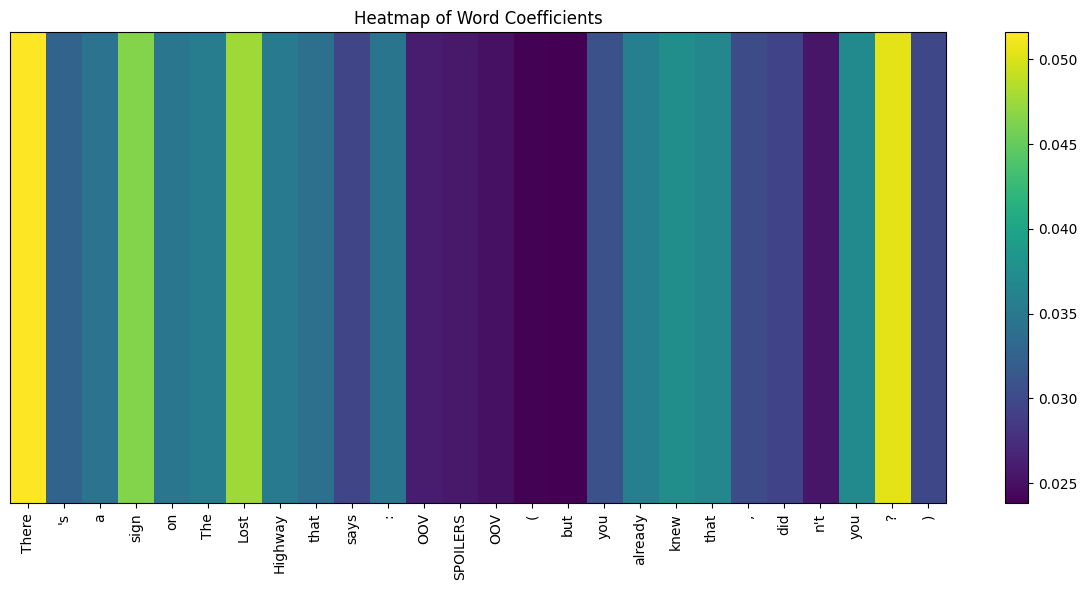

In [122]:



plt.figure(figsize=(12, 6)) 
plt.imshow(coefficients, cmap='viridis', aspect='auto')  
plt.colorbar()  


plt.xticks(ticks=np.arange(len(words[0])), labels=words[0], rotation=90)  #
plt.yticks([])  

plt.title('Heatmap of Word Coefficients')
plt.tight_layout() 
plt.show()


In [147]:
coefficients_total_array = np.array([coefficients_total])

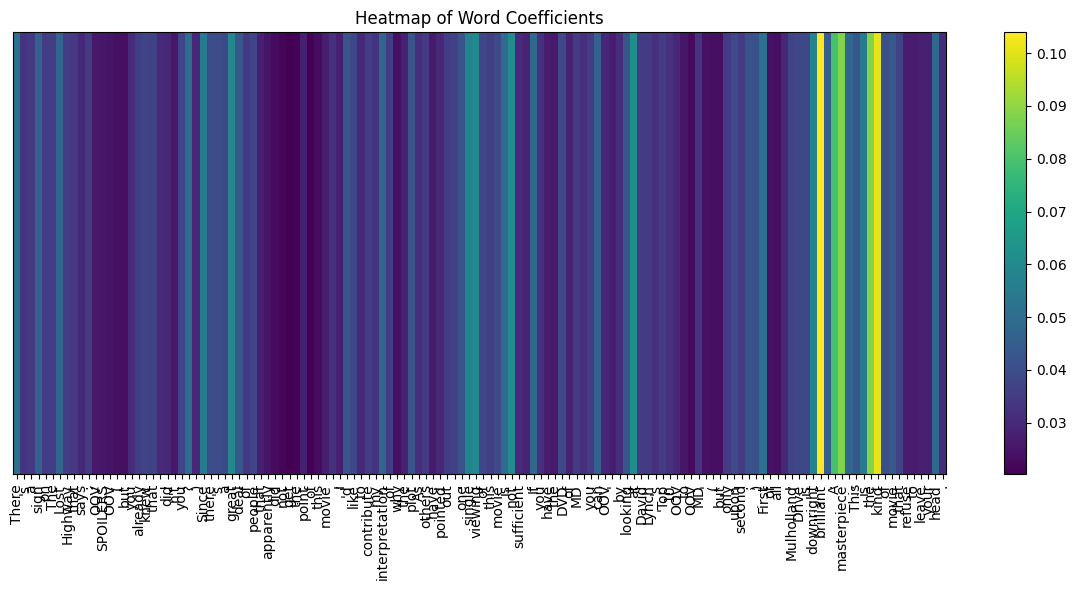

In [149]:


# Plotting the heatmap
plt.figure(figsize=(12, 6))  # Set figure size
plt.imshow(coefficients_total_array, cmap='viridis', aspect='auto')  # Plot the heatmap
plt.colorbar()  # Add a color bar

# Set the x-axis ticks to show the words
plt.xticks(ticks=np.arange(len(words_total)), labels=words_total, rotation=90)  # Rotate words 90 degrees
plt.yticks([])  # Hide y-axis ticks since we're not labeling the rows

plt.title('Heatmap of Word Coefficients')
plt.tight_layout()  # Adjust layout to fit the labels properly
plt.show()
